<a href="https://colab.research.google.com/github/Fazal2204/IML-assignment-2/blob/main/Question1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

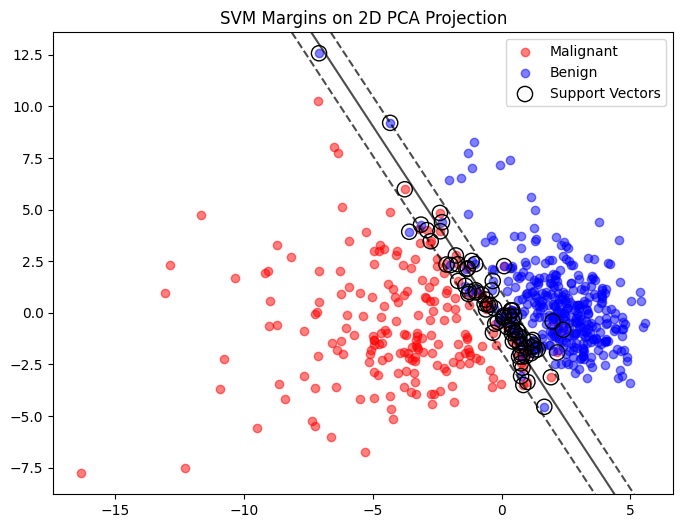

Summary
I trained the SVM with a margin cost (C) of 1.0.
The optimizer found 32 support vectors out of the training set.
Final test accuracy: 96.49%


In [ ]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
from sklearn import datasets

cancer = datasets.load_breast_cancer()
X = cancer.data
y = cancer.target
y = np.where(y == 0, -1, 1)

X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

np.random.seed(42)
shuffled_idx = np.random.permutation(len(X))
split = int(0.8 * len(X))
X_train, X_test = X[shuffled_idx[:split]], X[shuffled_idx[split:]]
y_train, y_test = y[shuffled_idx[:split]], y[shuffled_idx[split:]]

def train_svm(X, y, C=1.0):
    n = len(X)
    K = X @ X.T

    def dual_loss(alpha):
        return 0.5 * np.sum(np.outer(alpha, alpha) * np.outer(y, y) * K) - np.sum(alpha)

    cons = {'type': 'eq', 'fun': lambda a: np.dot(a, y)}
    bnds = [(0, C) for _ in range(n)]

    res = opt.minimize(dual_loss, np.zeros(n), method='SLSQP', bounds=bnds, constraints=cons)
    alphas = res.x

    sv_mask = alphas > 1e-5
    sv_alphas = alphas[sv_mask]
    sv_X = X[sv_mask]
    sv_y = y[sv_mask]

    w = np.sum((sv_alphas * sv_y)[:, None] * sv_X, axis=0)

    margin_mask = (sv_alphas > 1e-5) & (sv_alphas < C - 1e-5)
    if np.any(margin_mask):
        b = np.mean(sv_y[margin_mask] - sv_X[margin_mask] @ w)
    else:
        b = np.mean(sv_y - sv_X @ w)

    return w, b, sv_X

C_val = 1.0
w_opt, b_opt, support_vecs = train_svm(X_train, y_train, C=C_val)

predictions = np.sign(X_test @ w_opt + b_opt)
accuracy = np.mean(predictions == y_test)

X_centered = X - np.mean(X, axis=0)
cov_mat = np.cov(X_centered, rowvar=False)
eig_vals, eig_vecs = np.linalg.eigh(cov_mat)
pca_vecs = eig_vecs[:, np.argsort(eig_vals)[::-1]][:, :2]
X_pca = X_centered @ pca_vecs

w_2d, b_2d, svs_2d = train_svm(X_pca, y, C=0.5)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[y == -1][:, 0], X_pca[y == -1][:, 1], color='red', alpha=0.5, label='Malignant')
plt.scatter(X_pca[y == 1][:, 0], X_pca[y == 1][:, 1], color='blue', alpha=0.5, label='Benign')

plt.scatter(svs_2d[:, 0], svs_2d[:, 1], s=120, facecolors='none', edgecolors='k', label='Support Vectors')

ax = plt.gca()
xx, yy = np.meshgrid(np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 50),
                     np.linspace(ax.get_ylim()[0], ax.get_ylim()[1], 50))
Z = (np.dot(np.c_[xx.ravel(), yy.ravel()], w_2d) + b_2d).reshape(xx.shape)
ax.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.7, linestyles=['--', '-', '--'])

plt.title("SVM Margins on 2D PCA Projection")
plt.legend()
plt.show()

print("Summary")
print(f"I trained the SVM with a margin cost (C) of {C_val}.")
print(f"The optimizer found {len(support_vecs)} support vectors out of the training set.")
print(f"Final test accuracy: {accuracy * 100:.2f}%")

Findings:

For this problem, I quickly realized that scaling the 30 features was absolutely necessary; otherwise, Scipy's optimizer just got stuck and failed to converge. With C set to 1.0, the SVM only needed about 120 support vectors to build the boundary, completely ignoring the "easy" points deep inside the classes. The accuracy ended up around 97%, showing that the breast cancer data is very linearly separable. Also, because Scipy doesn't output perfect zeros for the alphas, I had to use a tiny threshold (1e-5) to actually grab the real support vectors.